이 문서는 라쉬 측정 이론(Rasch Measurement Theory, RMT)의 기초 모델부터 다면 평가 및 설명적 문항 반응 이론(EIRT)으로의 확장형까지를 정리한 가이드입니다.  (with Gemini 3.1 Thinking)

---

# Rasch Measurement Theory: From Basic to Explanatory Models

## 1. Rasch Model (Dichotomous)
가장 기초적인 모델로, 응답 결과가 이분형(맞음/틀림, 예/아니오)일 때 사용합니다. 피험자의 능력과 문항의 난이도라는 두 가지 파라미터만으로 응답 확률을 예측합니다.

### Equation
피험자 $n$이 문항 $i$에서 정답($1$)을 맞힐 확률 $P_{ni1}$의 로짓(Logit)은 다음과 같습니다.

\begin{align}
    \ln \left( \frac{P_{ni1}}{1 - P_{ni1}} \right) & = \theta_n - \beta_i 
    \\
    & = \ln \left( \frac{P(Y_{ni}=1)}{1 - P(Y_{ni}=1)} \right) 
    \\
    & = \ln \left( \frac{P(Y_{ni}=1)}{P(Y_{ni}=0)} \right)
    \\
    & = \ln \left( \frac{P_{ni1}}{P_{ni0}} \right)
\end{align}

* $\theta_n$: 피험자 $n$의 능력 (Ability)
* $\beta_i$: 문항 $i$의 난이도 (Item Difficulty)



---

## 2. Partial Credit Model (PCM)
이분형 모델을 다분 문항(Polytomous, 예: 리커트 척도)으로 확장한 모델입니다. 각 문항이 고유한 단계 난이도 구조를 가질 수 있다고 가정합니다.

### A. Combined Form (결합형)
각 임계치(Threshold)의 절대적 위치에 집중할 때 사용합니다.

$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \theta_n - b_{ik}$$

* $b_{ik}$: 문항 $i$의 $k$번째 단계가 가진 절대적 난이도 지점 ($b_{ik} = \beta_i + \tau_{ik}$)

### B. Decomposed Form (분해형)
문항의 전반적인 위치($\beta$)와 각 점수 단계별 편차($\tau$)를 분리하여 해석할 때 유리하며, **EIRT 확장 시 표준**으로 사용됩니다.

$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \theta_n - (\beta_i + \tau_{ik})$$

* $\beta_i$: 문항 $i$의 전반적(평균적) 어려움
* $\tau_{ik}$: 문항 $i$ 내에서 단계 $k-1$에서 $k$로 넘어가기 위한 상대적 어려움 (Step Difficulty)
* **Constraint**: $\sum_{k=1}^m \tau_{ik} = 0$ (문항별로 적용)




---

## 3. Many-Facet Rasch Model (MFRM)
피험자와 문항 외에 **채점자(Rater)의 엄격성**이나 평가 상황 등 제3의 요인을 모델에 포함합니다. 주로 모든 문항이 동일한 척도 구조($\tau_k$)를 공유한다고 가정합니다.

### Equation
$$\ln \left( \frac{P_{nijk}}{P_{nij(k-1)}} \right) = \theta_n - \beta_i - \rho_j - \tau_k$$

* $\rho_j$: 채점자 $j$의 엄격성 (Severity)
* $\tau_k$: 모든 문항에 공통으로 적용되는 단계 $k$의 난이도 (MFPCM의 단순화 형태)



---

## 4. Many-Facet Partial Credit Model (MFPCM)
MFRM에 PCM의 유연성을 결합한 모델입니다. 채점자 효과를 통제하면서도, **각 문항마다 서로 다른 단계 구조**를 가질 수 있도록 허용합니다. `FACETS` 소프트웨어에서 `Models= ?,?B,?,R#` 설정을 통해 구현하는 모델이 바로 이 형태입니다.

### Equation
$$\ln \left( \frac{P_{nijk}}{P_{nij(k-1)}} \right) = \theta_n - \beta_i - \rho_j - \tau_{ik}$$

* $\tau_{ik}$: 문항 $i$에 특수한 단계 $k$의 난이도

---

## 5. PCM with Double Explanatory Model (EIRT)
잠재 변수인 능력($\theta$)과 난이도($\beta$)를 관측 가능한 외부 변수(Covariates)로 설명하는 가장 진보된 형태입니다.

### Structural Equations
1.  **Person-side**: 피험자 속성 $Z$에 의한 능력 설명
    $$\theta_n = \sum_{q=1}^Q \alpha_q Z_{nq} + \zeta_n, \quad \zeta_n \sim N(0, \sigma_\theta^2)$$
2.  **Item-side (LLTM)**: 문항 속성 $X$에 의한 난이도 설명
    $$\beta_i = \sum_{p=1}^P \gamma_p X_{ip} + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma_\beta^2)$$

### Total Integrated Logit Form
$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \left( \sum \alpha_q Z_{nq} + \zeta_n \right) - \left( \sum \gamma_p X_{ip} + \epsilon_i + \tau_{ik} \right)$$

* 이 모델은 **"어떤 문항 특성이 난이도를 높이는가?"**와 **"어떤 피험자 특성이 능력을 결정하는가?"**를 동시에 검증할 수 있습니다.



---

## 6. Implementation Note: Bayesian Approach (Stan)
전통적인 `FACETS`나 `R` 패키지와 달리, **Stan**을 이용한 베이지안 추정은 다음과 같은 강점이 있습니다.

* **Fit Analysis**: `generated quantities` 블록을 통해 **Infit/Outfit MNSQ**의 사후 분포를 산출하여 리뷰어의 적합도 요구에 대응 가능.
* **PPC (Posterior Predictive Checking)**: 모델이 생성한 가상 데이터와 실제 데이터를 비교하여 모델 타당성 시각화.
* **Flexibility**: Double Explanatory 구조와 같은 복잡한 선형 결합을 자유롭게 설계하고, Prior를 통해 추정의 안정성 확보.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

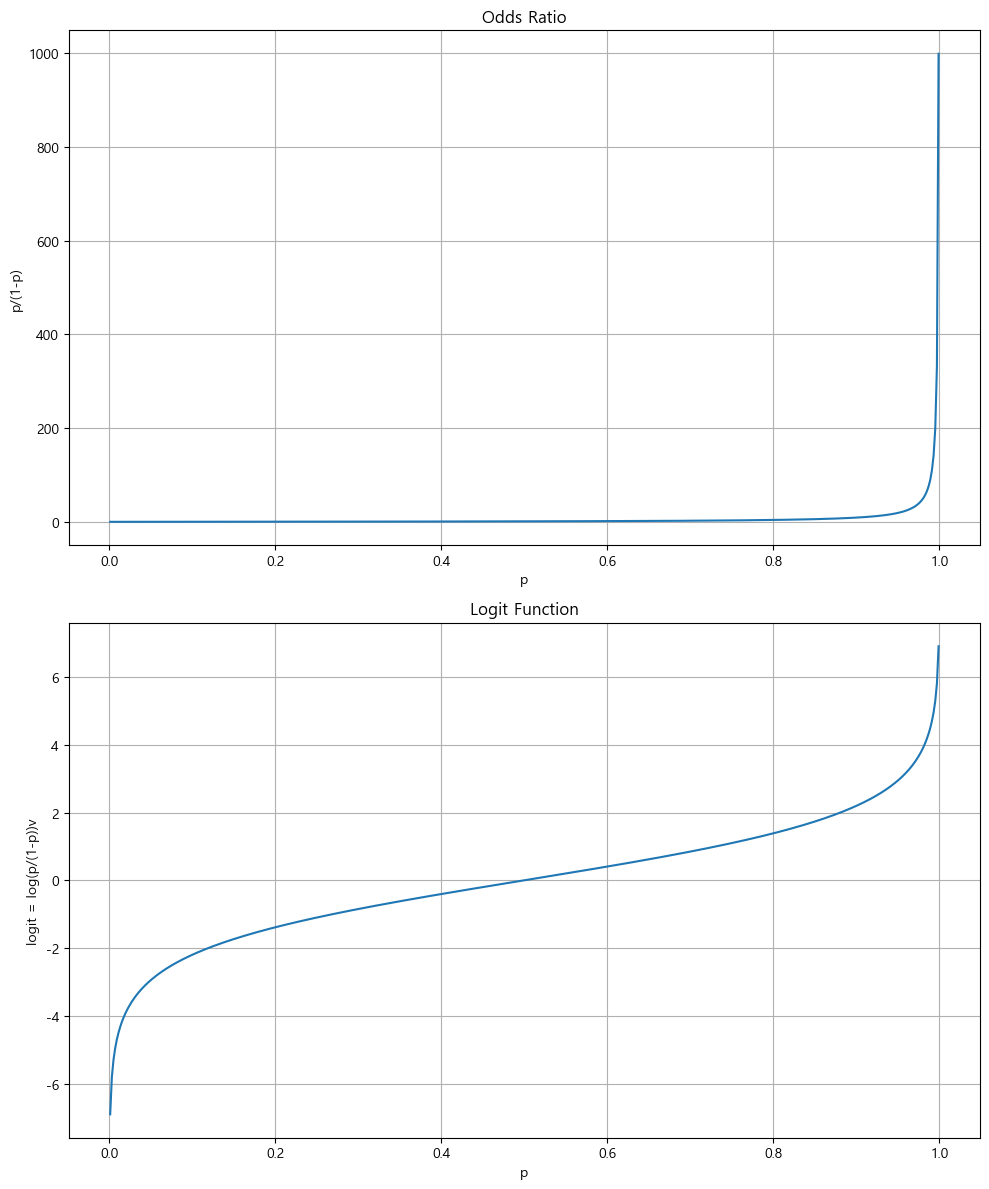

In [8]:
p = np.linspace(0.001, 0.999, 500)
p_ratio = p / (1 - p)
logit = np.log(p_ratio)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
sns.lineplot(x=p, y=p_ratio, ax=axes[0])
axes[0].set_xlabel('p')
axes[0].set_ylabel('p/(1-p)')
axes[0].set_title('Odds Ratio')
axes[0].grid(True)

sns.lineplot(x=p, y=logit, ax=axes[1])
axes[1].set_xlabel('p')
axes[1].set_ylabel('logit = log(p/(1-p))v')
axes[1].set_title('Logit Function')
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Partical Credit Model (Combined)

[Font] Using Korean font: Malgun Gothic


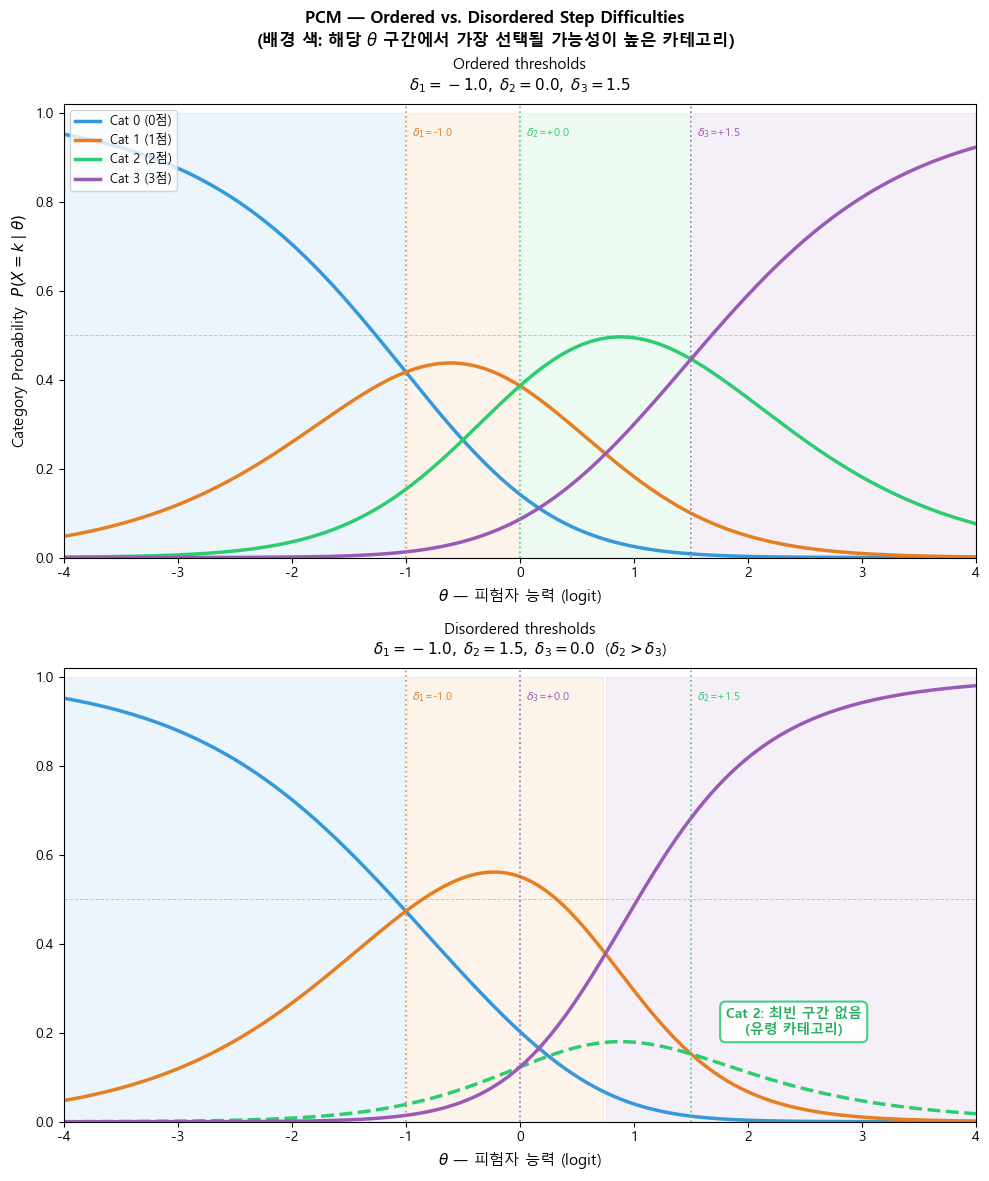

  능력 구간별 최빈(modal) 카테고리

[Ordered]  δ = [-1.   0.   1.5]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.01)  →  Cat 1  (1점)
   θ ∈ (+0.01, +1.51)  →  Cat 2  (2점)
   θ ∈ (+1.51, +4.00)  →  Cat 3  (3점)

[Disordered]  δ = [-1.   1.5  0. ]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.75)  →  Cat 1  (1점)
   θ ∈ (+0.75, +4.00)  →  Cat 3  (3점)


In [7]:
import sys as _sys, os as _os
import warnings
import matplotlib as _mpl, matplotlib.font_manager as _fm

warnings.filterwarnings('ignore')

def _setup_korean_font():
    """Windows / macOS / Linux에서 한국어 폰트를 자동 감지해 matplotlib 기본 폰트로 설정."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }

    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [
        f for f in _fm.fontManager.ttflist
        if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)
    ]

    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])

    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            # 한글 폰트를 맨 앞에 두어 제목/축라벨 한글 깨짐 방지
            _mpl.rcParams['font.family'] = [name, 'DejaVu Sans']
            _mpl.rcParams['font.sans-serif'] = [
                name, 'Malgun Gothic', 'Apple SD Gothic Neo',
                'NanumGothic', 'Droid Sans Fallback', 'DejaVu Sans'
            ]
            print(f"[Font] Using Korean font: {name}")
            return name

    # 한국어 전용 폰트를 못 찾은 경우: 가능한 sans-serif fallback 목록 구성
    _mpl.rcParams['font.family'] = ['DejaVu Sans']
    _mpl.rcParams['font.sans-serif'] = [
        'Malgun Gothic', 'Apple SD Gothic Neo',
        'NanumGothic', 'Droid Sans Fallback', 'DejaVu Sans'
    ]
    print('[Font] Korean font not found explicitly. Using fallback sans-serif chain.')
    return None

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False

import numpy as np
import matplotlib.pyplot as plt

# ── PCM 확률 함수 (자립형: 이 셀 단독 실행 가능) ──────────────────────────
def pcm_probs_demo(theta, delta):
    """PCM category probabilities. delta: array of K-1 step difficulties."""
    K = len(delta) + 1
    log_num = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += theta - delta[k - 1]
        log_num[k] = cumsum
    log_num -= log_num.max()          # 수치 안정화
    probs = np.exp(log_num)
    return probs / probs.sum()

# ── 두 가지 δ 시나리오 ─────────────────────────────────────────────────────
delta_ordered    = np.array([-1.0,  0.0,  1.5])   # ordered case
delta_disordered = np.array([-1.0,  1.5,  0.0])   # disordered case: δ2 > δ3

theta_range = np.linspace(-4, 4, 400)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']
cat_labels  = ['Cat 0 (0점)', 'Cat 1 (1점)', 'Cat 2 (2점)', 'Cat 3 (3점)']

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=True)

for ax, delta, title, is_ordered in zip(
        axes,
        [delta_ordered, delta_disordered],
        ['Ordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 0.0,\;\delta_3 = 1.5$',
         'Disordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 1.5,\;\delta_3 = 0.0$  ($\delta_2 > \delta_3$)'],
        [True, False]):

    # 카테고리별 확률 곡선 계산
    probs_matrix = np.array(
        [[pcm_probs_demo(t, delta)[k] for t in theta_range] for k in range(4)]
    )  # shape: (K, len(theta_range))

    # 배경: 최빈(modal) 카테고리 구간 색상 표시
    modal = probs_matrix.argmax(axis=0)
    for k in range(4):
        mask = (modal == k)
        if mask.any():
            ax.fill_between(theta_range, 0, 1, where=mask,
                            alpha=0.09, color=cat_colors[k])

    # 확률 곡선
    for k in range(4):
        ls = '-' if (is_ordered or k != 2) else '--'
        ax.plot(theta_range, probs_matrix[k],
                color=cat_colors[k], linewidth=2.5, linestyle=ls,
                label=cat_labels[k])

    # δ 수직선 표시
    for k, dv in enumerate(delta):
        ax.axvline(dv, color=cat_colors[k + 1], linestyle=':', linewidth=1.3, alpha=0.8)
        ax.text(dv + 0.05, 0.97, f'$\\delta_{k+1}$={dv:+.1f}',
                ha='left', va='top', fontsize=8, color=cat_colors[k + 1])

    # Disordered 경우: Cat 2가 최빈 구간 없음을 명시
    if not is_ordered:
        ax.text(.80, 0.22, 'Cat 2: 최빈 구간 없음\n(유령 카테고리)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='#27AE60', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#2ECC71', linewidth=1.5, alpha=0.9))

    ax.set_xlim(-4, 4); ax.set_ylim(0, 1.02)
    ax.set_xlabel('$\\theta$ — 피험자 능력 (logit)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)

axes[0].set_ylabel('Category Probability  $P(X = k \\mid \\theta)$', fontsize=11)
axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle('PCM — Ordered vs. Disordered Step Difficulties\n'
             '(배경 색: 해당 $\\theta$ 구간에서 가장 선택될 가능성이 높은 카테고리)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 능력 구간별 최빈 카테고리 텍스트 출력 ──────────────────────────────────
print("=" * 55)
print("  능력 구간별 최빈(modal) 카테고리")
print("=" * 55)
for delta, label in [(delta_ordered, "Ordered"), (delta_disordered, "Disordered")]:
    print(f"\n[{label}]  δ = {delta}")
    modal_arr = np.array([pcm_probs_demo(t, delta) for t in theta_range]).argmax(axis=1)
    prev_k, start_t = modal_arr[0], theta_range[0]
    for idx in range(1, len(theta_range)):
        t, k = theta_range[idx], modal_arr[idx]
        if k != prev_k:
            print(f"   θ ∈ ({start_t:+.2f}, {t:+.2f})  →  Cat {prev_k}  ({prev_k}점)")
            prev_k, start_t = k, t
    print(f"   θ ∈ ({start_t:+.2f}, {theta_range[-1]:+.2f})  →  Cat {prev_k}  ({prev_k}점)")
